In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Caminho do arquivo original
arquivo = "Residencial.csv"

In [3]:
# Lê o CSV, pulando as primeiras 5 linhas e usando o separador ";"
df = pd.read_csv(arquivo, skiprows=5, sep=";")

In [4]:
# Filtra apenas a linha da região Sudeste e a coluna "ANO"
sudeste_ano = df.loc[df["Unnamed: 0"] == "Sudeste", ["Unnamed: 0", "ANO"]]

In [5]:
# Renomeia as colunas para nomes mais claros
sudeste_ano.columns = ["Região", "Consumo_Anual_MWh"]

In [6]:
anos = list(range(2024,2005,-1))

In [7]:
sudeste_ano.insert(0, "Ano", anos[:len(sudeste_ano)])

In [8]:
# Salva o resultado em um novo arquivo CSV
sudeste_ano.to_csv("sudeste_ano.csv", index=False)

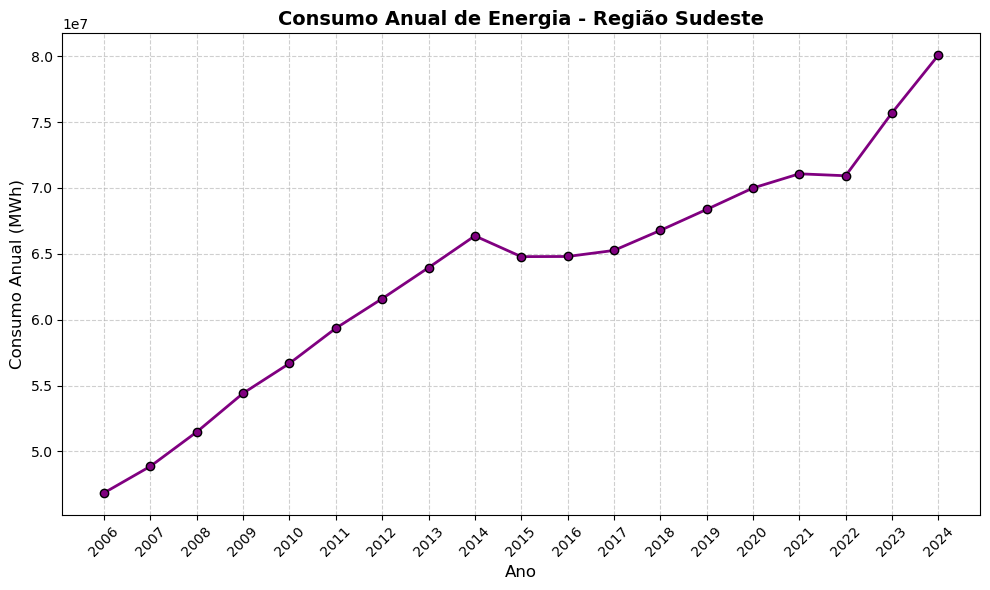

In [9]:
# Converte a coluna para número (removendo pontos)
sudeste_ano["Consumo_Anual_MWh"] = (
    sudeste_ano["Consumo_Anual_MWh"]
    .astype(str)
    .str.replace(".", "", regex=False)  # remove separador de milhar
)
sudeste_ano["Consumo_Anual_MWh"] = pd.to_numeric(sudeste_ano["Consumo_Anual_MWh"], errors="coerce")

# Cria o gráfico
plt.figure(figsize=(10,6))
plt.plot(
    sudeste_ano["Ano"],
    sudeste_ano["Consumo_Anual_MWh"],
    color='purple',
    marker='o',
    markerfacecolor='purple',
    markeredgecolor='black',
    linewidth=2
)

# Título e rótulos
plt.title("Consumo Anual de Energia - Região Sudeste", fontsize=14, fontweight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Consumo Anual (MWh)", fontsize=12)

# Exibe todos os anos no eixo X
plt.xticks(sudeste_ano["Ano"], rotation=45)

# Grade visual
plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.savefig("Consumo de energia residencial SE.pdf")
plt.show()